# <center>pandas: DataFrames, transformation, and visualization</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: fundamentals of research in python</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* Use the `Series` and `DataFrame`, and recognize **index alignment**, arithmetic on labelled data aligns by label, not by position, as the feature that distinguishes pandas from NumPy.

* Choose an index deliberately, verify that it identifies, and distinguish `.loc` from `.iloc`.

* Handle missing values, and know why an integer column with one hole silently becomes `float64` under the legacy dtypes and stays integer under the nullable ones.

* Read and write CSV, Parquet and Excel, and say what each format does and does not preserve.

* Apply the **split–apply–combine** pattern: aggregate, transform (the within transformation of the fixed-effects estimator), and filter.

* Combine tables with `merge` and `concat`, and reshape with `pivot`, `melt`, `stack` and `unstack`.

* **Build the matching matrix $\mu_{xy}$ from real micro data**, Choo and Siow's marriage census, verify the mass-balance identity it must satisfy, and recognize the `MultiIndex` that comes out as the index map of `fd02`, now carrying names and built from data rather than by hand.

### References

**[M]** McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly, Chapters 5, 8, 10. https://wesmckinney.com/book/.

**[W]** Wickham, H. (2014). "Tidy Data." *Journal of Statistical Software* 59(10): the long/wide distinction of §13.

**[CS]** Choo, E. and Siow, A. (2006). "Who Marries Whom and Why." *Journal of Political Economy* 114(1), 175–201: the data of §15.

**[G]** Galichon, A. (2016). *Optimal Transport Methods in Economics*. Princeton University Press, Chapter 8: the separable matching model estimated on these data.

**[B]** Becker, G. S. (1973). "A Theory of Marriage: Part I." *Journal of Political Economy* 81(4), 813–846.

## 1. Motivation

NumPy gives you the array: a contiguous block of homogeneous numbers, indexed by position. pandas gives you the **labelled** array: rows have names (the *index*), columns have names, and the dtype may vary from column to column. Almost every empirical analysis in economics passes through it.

Three reasons:

* **Heterogeneous columns.** A wage is a float, a country code is a string, a treatment indicator is a boolean. NumPy can hold them together only by collapsing to `object` dtype and giving up the speed; pandas keeps each column at its native dtype.
* **Missing data, properly.** Real data has holes, and pandas has `NaN`/`NA` semantics that propagate through arithmetic, group-bys and joins.
* **Index alignment.** Operations align by *label*, not by position. This is the conceptual feature, and §2 shows why it matters.

The lecture comes in two halves. **Part I (§§2–9)** is the data model: Series, DataFrame, indexes, dtypes, and file formats. **Part II (§§10–15)** is what you do with it: split–apply–combine, joins, reshaping, and plotting.

It ends where `fd02` began. `fd02` §12 built an index map from a pair $(x,y)$ to a position in a flat vector by hand, on four workers and three firms invented for the purpose. §15 below builds the same object from **real marriage-census micro data**, sixty age groups on each side, thirty-six hundred pairs, with `groupby` and `unstack` doing the work, and the `MultiIndex` that comes out is that index map, now carrying names and derived rather than declared.

That matrix is what the last four lectures of the series run on. `fd08` §13 gives its flattening a name and assembles a constraint matrix around it; `fd09` §6 solves the resulting transport problem and reads the multipliers as wages. The data comes first here, and the algebra follows.

### Two things from NumPy, first

pandas is built on **NumPy**, and two of its pieces show through often enough to be worth ninety seconds now. `fd08` treats both properly; this is the minimum to read the code below.

An **`ndarray`** is a block of memory holding values of one type, its `dtype`, laid out contiguously. That is what makes it fast: no per-element Python object, and arithmetic that runs in compiled code over the whole block at once. Every `Series` stores its values in one, and `.values` hands it to you with the labels stripped off.

A **`Generator`** is NumPy's random number source. You create one with an explicit seed, `rng = np.random.default_rng(0)`, and draw from it by method: `rng.normal`, `rng.integers`, `rng.choice`. The seed is what makes §7's synthetic panel identical on your machine and mine; `fd07` §10 made this item 3 of the reproducibility checklist, and `fd08` §16 explains why the explicit generator is the only acceptable form.

In [1]:
import numpy as np
import pandas as pd

arr = np.array([3.1, 4.1, 5.9, 2.6])
print(f"ndarray {arr!r}\n  dtype {arr.dtype}, shape {arr.shape}, {arr.nbytes} bytes")
print(f"  whole-array arithmetic: {arr * 2}")

s_labelled = pd.Series(arr, index=["a", "b", "c", "d"])
print(f"\na Series wraps one: type(s.values) = {type(s_labelled.values).__name__}, "
      f"same memory = {s_labelled.values.base is arr or s_labelled.values is arr}")

rng = np.random.default_rng(0)
print(f"\nrng.normal(size=3)   {rng.normal(size=3).round(4)}")
print(f"rng.integers(1, 7, 3) {np.random.default_rng(0).integers(1, 7, 3)}")
print(f"same seed, same draws: {np.random.default_rng(0).normal(size=3).round(4)}")

ndarray array([3.1, 4.1, 5.9, 2.6])
  dtype float64, shape (4,), 32 bytes
  whole-array arithmetic: [ 6.2  8.2 11.8  5.2]

a Series wraps one: type(s.values) = ndarray, same memory = True

rng.normal(size=3)   [ 0.1257 -0.1321  0.6404]
rng.integers(1, 7, 3) [6 4 4]
same seed, same draws: [ 0.1257 -0.1321  0.6404]


# Part I: the data model

## 2. The `Series`: a labelled array, and index alignment

A `Series` is a one-dimensional array plus an index.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gdp = pd.Series([25.46, 17.96, 4.23, 4.07, 3.07],
                index=["USA", "China", "Japan", "Germany", "UK"],
                name="gdp_2022")

print(gdp)
print(f"\nvalues {type(gdp.values).__name__}, index {gdp.index.name}, dtype {gdp.dtype}")
print(f"\nby label {gdp['USA']}, by position {gdp.iloc[0]}, by mask {gdp[gdp > 5].tolist()}")

USA        25.46
China      17.96
Japan       4.23
Germany     4.07
UK          3.07
Name: gdp_2022, dtype: float64

values ndarray, index None, dtype float64

by label 25.46, by position 25.46, by mask [25.46, 17.96]


**Index alignment is the distinctive feature.** Arithmetic on two Series aligns by *label*. Labels present in only one operand produce `NaN` rather than a silent positional mismatch.

In [3]:
s1 = pd.Series([1.0, 2.0, 3.0], index=["a", "b", "c"])
s2 = pd.Series([10.0, 20.0, 30.0], index=["b", "c", "d"])

print(s1 + s2)
print("\nNumPy would have summed by position and told you nothing:")
print(s1.values + s2.values)

a     NaN
b    12.0
c    23.0
d     NaN
dtype: float64

NumPy would have summed by position and told you nothing:
[11. 22. 33.]


`b` and `c` appear in both, so they add. `a` is only in `s1` and `d` only in `s2`, so both are `NaN`: pandas refuses to guess and reports the misalignment. NumPy, adding the raw arrays, silently pairs `a` with `b`, `b` with `c`, `c` with `d`, and returns three plausible wrong numbers.

This is invaluable when combining sources with different date ranges or country sets, and dangerous when you did not expect it. It deserves one extra glance at every `+`, `-`, `*`, `/` on Series until the habit is automatic.

## 3. The `DataFrame`

A `DataFrame` is a dict of Series sharing an index: a labelled table whose columns may have different dtypes.

In [4]:
df = pd.DataFrame({
    "gdp": [25.46, 17.96, 4.23, 4.07, 3.07, 2.78],
    "population": [333.0, 1412.0, 125.0, 84.0, 67.0, 68.0],
    "currency": ["USD", "CNY", "JPY", "EUR", "GBP", "EUR"],
}, index=["USA", "China", "Japan", "Germany", "UK", "France"])
df.index.name = "country"

print(df)
print(f"\nshape {df.shape}, dtypes {df.dtypes.to_dict()}")

df["gdp_per_capita"] = df["gdp"] * 1e6 / df["population"]      # whole-column arithmetic
print(f"\n{df[['gdp', 'population', 'gdp_per_capita']].round(1)}")

           gdp  population currency
country                            
USA      25.46       333.0      USD
China    17.96      1412.0      CNY
Japan     4.23       125.0      JPY
Germany   4.07        84.0      EUR
UK        3.07        67.0      GBP
France    2.78        68.0      EUR

shape (6, 3), dtypes {'gdp': dtype('float64'), 'population': dtype('float64'), 'currency': dtype('O')}

          gdp  population  gdp_per_capita
country                                  
USA      25.5       333.0         76456.5
China    18.0      1412.0         12719.5
Japan     4.2       125.0         33840.0
Germany   4.1        84.0         48452.4
UK        3.1        67.0         45820.9
France    2.8        68.0         40882.4


Two forms of column access exist: `df["gdp"]` and `df.gdp`, and they return the same Series. Prefer the bracket form: the attribute form fails for columns whose names clash with methods (a column called `count`, `mean`, or `index`) or contain spaces, and it cannot be used to *create* a column.

## 4. Indexes are first-class

A meaningful index, a country code, a ticker, a date, buys label-based slicing and automatic alignment in joins. The default integer index left by `read_csv` buys nothing, so promote a key column when you have one.

**And verify that it identifies.** An index meant to identify observations must be unique. Duplicated keys raise no error at creation and then silently corrupt lookups, joins and panel logic. Check with `.index.is_unique`, or fail loudly at creation with `verify_integrity=True`.

In [5]:
df_flat = df.reset_index()                      # index becomes an ordinary column
print(df_flat.head(3))
print(f"\nindex is unique: {df_flat.set_index('country').index.is_unique}")

# a duplicated key: no error, and lookups silently return two rows
dup = pd.DataFrame({"country": ["USA", "USA"], "gdp": [25.46, 25.50]})
print(f"duplicated key is unique: {dup.set_index('country').index.is_unique}")
print(f"lookup returns {len(dup.set_index('country').loc['USA'])} rows, not 1")

try:
    dup.set_index("country", verify_integrity=True)
except ValueError as err:
    print(f"\nverify_integrity=True -> ValueError: {err}")

  country    gdp  population currency  gdp_per_capita
0     USA  25.46       333.0      USD    76456.456456
1   China  17.96      1412.0      CNY    12719.546742
2   Japan   4.23       125.0      JPY    33840.000000

index is unique: True
duplicated key is unique: False
lookup returns 2 rows, not 1

verify_integrity=True -> ValueError: Index has duplicate keys: Index(['USA'], dtype='object', name='country')


## 5. `.loc` versus `.iloc`

`.iloc` indexes by **position**, `.loc` by **label**. The distinction matters most in slicing, where `.loc` is *end-inclusive* and `.iloc` is not.

In [6]:
print("iloc[0, 0]           :", df.iloc[0, 0], "  (first row, first column, by position)")
print("loc['USA', 'gdp']    :", df.loc["USA", "gdp"], "  (by label)")
print("\niloc[:3, :2] -- end EXCLUSIVE, 3 rows:")
print(df.iloc[:3, :2])
print("\nloc['Japan':'UK', ['gdp']] -- end INCLUSIVE:")
print(df.loc["Japan":"UK", ["gdp"]])
print("\nboolean mask with .loc:")
print(df.loc[df["gdp"] > 5, ["gdp", "population"]])

iloc[0, 0]           : 25.46   (first row, first column, by position)
loc['USA', 'gdp']    : 25.46   (by label)

iloc[:3, :2] -- end EXCLUSIVE, 3 rows:
           gdp  population
country                   
USA      25.46       333.0
China    17.96      1412.0
Japan     4.23       125.0

loc['Japan':'UK', ['gdp']] -- end INCLUSIVE:
          gdp
country      
Japan    4.23
Germany  4.07
UK       3.07

boolean mask with .loc:
           gdp  population
country                   
USA      25.46       333.0
China    17.96      1412.0


> **Why is `.loc` slicing end-inclusive?** Because labels have no natural successor: `"Italy" + 1` is meaningless. End-inclusive is the only convention under which `df.loc["a":"e"]` is a question you can answer without first knowing what comes after `"e"`.

Plain `df[...]` is for columns: `df["gdp"]` returns a column, but `df[df["gdp"] > 5]` filters *rows*. That inconsistency is historical. Use `.loc` when you mean rows and you will never have to think about it.

## 6. Missing values and dtypes

pandas has two generations of machinery for missingness.

* **Legacy (NumPy-based).** The only missing marker NumPy offers is `NaN`, which is a *float*. So a float column can hold missing values natively and no other dtype can: an integer column with one hole is silently promoted to `float64`, a boolean column falls back to `object`.
* **Modern (nullable).** The extension dtypes `Int64`, `Float64`, `boolean`, `string`, note the capitals, store a separate boolean *mask* alongside the values. Because missingness lives in the mask rather than in the values, an integer column with a hole *stays* integer.

You will meet both.

In [7]:
s = pd.Series([1.0, 2.0, np.nan, 4.0, np.nan], name="x")
print(f"sum {s.sum()}, mean {s.mean():.4f}          <- reductions skip NA by default")
print(f"sum(skipna=False) {s.sum(skipna=False)}     <- unless you say otherwise")
print(f"NaN + 5 = {np.nan + 5}                      <- arithmetic propagates")

legacy = pd.Series([1, 2, None, 4])                  # legacy: promoted to float
modern = pd.Series([1, 2, None, 4], dtype="Int64")   # nullable: stays integer

print(f"\nlegacy dtype {legacy.dtype}: {legacy.tolist()}")
print(f"modern dtype {modern.dtype}: {modern.tolist()}")
assert legacy.dtype == "float64" and modern.dtype == "Int64"
print("\ncheck passed: a hole costs the legacy column its integer dtype.")

sum 7.0, mean 2.3333          <- reductions skip NA by default
sum(skipna=False) nan     <- unless you say otherwise
NaN + 5 = nan                      <- arithmetic propagates

legacy dtype float64: [1.0, 2.0, nan, 4.0]
modern dtype Int64: [1, 2, <NA>, 4]

check passed: a hole costs the legacy column its integer dtype.


## 7. A worked dataset: a synthetic wage panel

For the rest of Part I we need a table with some texture: several dtypes, a categorical, and some missing values. We generate a Mincer-flavoured wage cross-section with the seeded `Generator` of §1.

In [8]:
rng = np.random.default_rng(42)
I = 500

educ_i = rng.integers(8, 18, size=I)
exper_i = rng.integers(0, 30, size=I)
female_i = rng.integers(0, 2, size=I).astype(bool)
married_i = rng.integers(0, 2, size=I).astype(bool)
sector_i = rng.choice(["mfg", "services", "agri", "public"], size=I,
                      p=[0.20, 0.55, 0.05, 0.20])

log_wage_i = (0.5 + 0.08 * educ_i + 0.04 * exper_i - 0.001 * exper_i ** 2
              - 0.20 * female_i + 0.10 * married_i
              + rng.normal(0, 0.30, size=I))

exper_na_i = exper_i.astype(float)
exper_na_i[rng.choice(I, 12, replace=False)] = np.nan        # 12 deliberate holes

panel = pd.DataFrame({"wage": np.exp(log_wage_i).round(2),
                      "educ": educ_i,
                      "exper": exper_na_i,
                      "female": female_i,
                      "married": married_i,
                      "sector": sector_i})

print(panel.head())
print(f"\nshape {panel.shape}; missing values per column:")
print(panel.isna().sum().to_string())

   wage  educ  exper  female  married    sector
0  4.22     8    3.0    True     True       mfg
1  5.37    15   19.0    True    False  services
2  4.48    14   28.0    True    False       mfg
3  5.82    12   26.0    True    False       mfg
4  8.27    12    8.0   False     True  services

shape (500, 6); missing values per column:
wage        0
educ        0
exper      12
female      0
married     0
sector      0


## 8. Reading and writing files

Three formats cover almost every workflow, and they differ in exactly one respect that matters: **what they preserve about dtypes.** Everything written here goes into a `generated/` subfolder: the hygiene of `fd05`, applied to notebook byproducts.

* **CSV**: plain text, universally readable, and carries *no dtype metadata*. It is the format you receive data in, rarely the one to keep it in.
* **Parquet**: columnar, compressed, and stores the schema alongside the data. If you control both ends of the pipe, use it.
* **Excel**: what collaborators send you.

The demonstration below builds a table with a datetime, a category and a nullable integer, and round-trips it through both formats.

In [9]:
from pathlib import Path

OUT_DIR = Path("generated")
OUT_DIR.mkdir(exist_ok=True)

typed = pd.DataFrame({
    "date": pd.to_datetime(["2024-01-31", "2024-02-29", "2024-03-31"]),
    "sector": pd.Categorical(["mfg", "services", "mfg"]),
    "count": pd.array([10, None, 7], dtype="Int64"),
    "wage": [21.5, 33.0, 28.25],
})
print("original dtypes:")
print(typed.dtypes.to_string())

typed.to_csv(OUT_DIR / "typed.csv", index=False)
typed.to_parquet(OUT_DIR / "typed.parquet")

back_csv = pd.read_csv(OUT_DIR / "typed.csv")
back_parquet = pd.read_parquet(OUT_DIR / "typed.parquet")

print("\nafter a CSV round trip:")
print(back_csv.dtypes.to_string())
print("\nafter a Parquet round trip:")
print(back_parquet.dtypes.to_string())

assert (back_parquet.dtypes == typed.dtypes).all()
assert not (back_csv.dtypes == typed.dtypes).all()
print("\ncheck passed: Parquet preserves every dtype; CSV loses three of four.")

original dtypes:
date      datetime64[ns]
sector          category
count              Int64
wage             float64



after a CSV round trip:
date       object
sector     object
count     float64
wage      float64

after a Parquet round trip:
date      datetime64[ns]
sector          category
count              Int64
wage             float64

check passed: Parquet preserves every dtype; CSV loses three of four.


In [10]:
# and the size comparison
panel.to_csv(OUT_DIR / "panel.csv", index=False)
panel.to_parquet(OUT_DIR / "panel.parquet")

sizes = {f.name: f.stat().st_size for f in
         (OUT_DIR / "panel.csv", OUT_DIR / "panel.parquet")}
for name, size in sizes.items():
    print(f"{name:<18}{size:>9,} bytes")
print(f"\nParquet is {sizes['panel.csv'] / sizes['panel.parquet']:.1f}x smaller here, "
      f"and the gap widens with row count.")

# the CSV round trip of `panel` happens to be clean -- because its dtypes are all easy
back = pd.read_csv(OUT_DIR / "panel.csv")
print(f"panel survives CSV: {(back.dtypes == panel.dtypes).all()}  "
      f"(floats, small ints, True/False strings -- the easy cases)")

panel.csv            15,886 bytes
panel.parquet         7,670 bytes

Parquet is 2.1x smaller here, and the gap widens with row count.


panel survives CSV: True  (floats, small ints, True/False strings -- the easy cases)


Arguments to `read_csv` useful on day one: `parse_dates=["date"]`, `index_col="id"`, `dtype={"educ": "Int64"}`, `na_values=["", ".", "NA"]`, `usecols=[...]`, and `nrows=1000` for a sanity check before reading a large file.

## 9. Three pitfalls

**1. `SettingWithCopyWarning`.** Some indexing returns a view, some a copy, and the rules are subtle. When you mean to assign, use `.loc`:

```python
df.loc[df["x"] > 0, "y"] = 1     # safe
df[df["x"] > 0]["y"] = 1         # ambiguous; warns, and may do nothing
```

**2. Chained indexing.** `df["a"]["b"]` works but is fragile. Write `df.loc["a", "b"]`.

**3. `inplace=True`.** Most methods return a new object by default. `inplace=True` is discouraged in modern pandas: it does not avoid the internal copy, so it is not faster, and it does not compose with method chains. Reassign instead: `df = df.drop(columns="foo")`.

# Part II: transformation, aggregation, visualization

## 10. `groupby`: split, apply, combine

The single most important operation in pandas, in three steps:

1. **Split** the rows into groups by one or more keys.
2. **Apply** a function to each group.
3. **Combine** the results.

A `groupby` call does no work by itself; it returns an object holding the plan. The work happens when a method is called on it.

In [11]:
g = panel.groupby("sector")
print("group sizes:")
print(g.size().to_string())
print("\nmean wage by sector:")
print(g["wage"].mean().round(2).to_string())

# the keys become the INDEX of the result; as_index=False keeps them as columns
flat = panel.groupby("sector", as_index=False)["wage"].mean().round(2)
print(f"\nas_index=False gives a flat frame:\n{flat}")

group sizes:
sector
agri         21
mfg         104
public      110
services    265

mean wage by sector:
sector
agri        5.29
mfg         5.73
public      5.81
services    6.03

as_index=False gives a flat frame:
     sector  wage
0      agri  5.29
1       mfg  5.73
2    public  5.81
3  services  6.03


**Several keys give a `MultiIndex`.** This is the object §15 is built on, so it is worth looking at closely: the result is indexed by the *pair*, and `unstack` turns one level into columns: converting a long-format Series into a rectangular table.

In [12]:
by_pair = panel.groupby(["sector", "female"])["wage"].mean().round(2)
print("long form, MultiIndex on (sector, female):")
print(by_pair.to_string())

print("\nunstacked -- 'female' becomes the columns:")
print(by_pair.unstack("female").round(2))

long form, MultiIndex on (sector, female):
sector    female
agri      False     5.92
          True      4.72
mfg       False     6.73
          True      4.84
public    False     6.43
          True      5.11
services  False     6.74
          True      5.34

unstacked -- 'female' becomes the columns:
female    False  True 
sector                
agri       5.92   4.72
mfg        6.73   4.84
public     6.43   5.11
services   6.74   5.34


## 11. Aggregate, transform, filter

Three things to do with a grouped object, distinguished by the *shape* of what comes back.

* **Aggregate**: one row per group. `mean`, `sum`, `count`, `std`, `quantile`, or anything you write.
* **Transform**: same shape as the input, computed group-wise. Group demeaning, group ranks.
* **Filter**: keep or drop whole groups.

In [13]:
# named aggregations: the cleanest output
summary = panel.groupby("sector").agg(
    n=("wage", "size"),
    mean_wage=("wage", "mean"),
    median_wage=("wage", "median"),
    iqr=("wage", lambda x: x.quantile(0.75) - x.quantile(0.25)),
    mean_educ=("educ", "mean"),
).round(2)
print(summary)

# transform: the WITHIN transformation of the fixed-effects estimator
panel["wage_demeaned"] = panel["wage"] - panel.groupby("sector")["wage"].transform("mean")
within_means = panel.groupby("sector")["wage_demeaned"].mean()
print(f"\ngroup means after demeaning: max |mean| = {within_means.abs().max():.2e}")
assert within_means.abs().max() < 1e-12
print("check passed: the within transformation annihilates group means (tolerance 1e-12).")

# filter: drop small groups
kept = panel.groupby("sector").filter(lambda x: len(x) >= 50)
print(f"\nfiltering to sectors with >= 50 observations drops "
      f"{set(panel['sector']) - set(kept['sector'])}, leaving {len(kept)} rows")

            n  mean_wage  median_wage   iqr  mean_educ
sector                                                
agri       21       5.29         5.57  2.88      12.86
mfg       104       5.73         5.28  3.21      12.35
public    110       5.81         5.28  3.19      12.11
services  265       6.03         5.65  3.27      12.66

group means after demeaning: max |mean| = 4.10e-16
check passed: the within transformation annihilates group means (tolerance 1e-12).

filtering to sectors with >= 50 observations drops {'agri'}, leaving 479 rows


The transform above is worth naming: subtracting the group mean is the **within transformation**, and running OLS on the demeaned data is the fixed-effects estimator. That the demeaned column has exactly zero group means is not a coincidence but the defining property: it is why fixed effects removes anything constant within a group, and why it cannot identify a regressor that is itself constant within groups.

## 12. Combining tables: `merge` and `concat`

Two different operations. **`merge`** is a relational join on key *values*; **`concat`** stacks along an axis, aligning on the *index*. Use `merge` for a foreign-key relationship, `concat` for more rows of the same kind.

In [14]:
sector_info = pd.DataFrame({
    "sector": ["mfg", "services", "agri", "public"],
    "capital_intensity": [0.62, 0.31, 0.48, 0.25],
    "union_rate": [0.28, 0.09, 0.15, 0.42],
})

merged = panel.merge(sector_info, on="sector", how="left")
print(f"panel {panel.shape} + sector_info {sector_info.shape} -> {merged.shape}")
print(f"unmatched rows: {merged['capital_intensity'].isna().sum()}")

# a merge that loses rows, silently
partial = sector_info.query("sector != 'agri'")
inner = panel.merge(partial, on="sector", how="inner")
left = panel.merge(partial, on="sector", how="left")
print(f"\nwith 'agri' missing from the right table:")
print(f"  how='inner': {len(inner)} rows  <- {len(panel) - len(inner)} rows SILENTLY DROPPED")
print(f"  how='left' : {len(left)} rows, {left['capital_intensity'].isna().sum()} with NaN")

panel (500, 7) + sector_info (4, 3) -> (500, 9)
unmatched rows: 0

with 'agri' missing from the right table:
  how='inner': 479 rows  <- 21 rows SILENTLY DROPPED
  how='left' : 500 rows, 21 with NaN


| `how` | rows in the result |
|---|---|
| `"inner"` (default) | only keys present in both |
| `"left"` | all rows of the left frame, `NaN` where unmatched |
| `"right"` | the mirror image |
| `"outer"` | all keys from either side |

The default is `"inner"`, and it **drops rows without telling you**: the most common silent data-loss bug in applied work. Two habits prevent it: check `len` before and after every merge, and pass `validate=` to assert the relationship you believe holds.

In [15]:
# validate= turns an assumption into a checked precondition
ok = panel.merge(sector_info, on="sector", how="left", validate="many_to_one")
print(f"validate='many_to_one' passed: {ok.shape}")

dup_info = pd.concat([sector_info, sector_info.head(1)], ignore_index=True)
try:
    panel.merge(dup_info, on="sector", how="left", validate="many_to_one")
except pd.errors.MergeError as err:
    print(f"\nwith a duplicated key on the right -> MergeError: {err}")
print("\nwithout validate=, that duplicate would silently have DUPLICATED rows of panel.")

validate='many_to_one' passed: (500, 9)

with a duplicated key on the right -> MergeError: Merge keys are not unique in right dataset; not a many-to-one merge

without validate=, that duplicate would silently have DUPLICATED rows of panel.


## 13. Reshaping: `pivot`, `melt`, `stack`, `unstack`

Two layouts for the same data. **Long**: one row per observation, which is what `groupby` and seaborn like. **Wide**: rows are entities and columns are variables, which is what humans read. Wickham calls long format *tidy*.

`pivot` and `unstack` go long → wide; `melt` and `stack` go wide → long. The pair `stack`/`unstack` operate on the *index* and are the ones §15 needs.

In [16]:
long = panel.groupby(["sector", "female"], as_index=False)["wage"].mean().round(2)
print("long format:")
print(long)

wide = long.pivot(index="sector", columns="female", values="wage")
print("\nwide (pivot):")
print(wide)

back_long = wide.melt(ignore_index=False, value_name="wage").reset_index()
print(f"\nmelt returns it to long: {back_long.shape} rows, matching {long.shape}")

# pivot requires (index, columns) to be unique; pivot_table aggregates duplicates
pt = panel.pivot_table(index="sector", columns="female", values="wage", aggfunc="mean")
print(f"\npivot_table on the raw panel (aggregates duplicates):\n{pt.round(2)}")

long format:
     sector  female  wage
0      agri   False  5.92
1      agri    True  4.72
2       mfg   False  6.73
3       mfg    True  4.84
4    public   False  6.43
5    public    True  5.11
6  services   False  6.74
7  services    True  5.34

wide (pivot):
female    False  True 
sector                
agri       5.92   4.72
mfg        6.73   4.84
public     6.43   5.11
services   6.74   5.34

melt returns it to long: (8, 3) rows, matching (8, 3)

pivot_table on the raw panel (aggregates duplicates):
female    False  True 
sector                
agri       5.92   4.72
mfg        6.73   4.84
public     6.43   5.11
services   6.74   5.34


## 14. Visualization

matplotlib is the engine; seaborn sits on top and shortens the common statistical plots. Use the **explicit** matplotlib API: `fig, ax = plt.subplots()`, then methods on `ax`: rather than the implicit `plt.plot(...)` state machine, which is convenient at a prompt and fragile in a script.

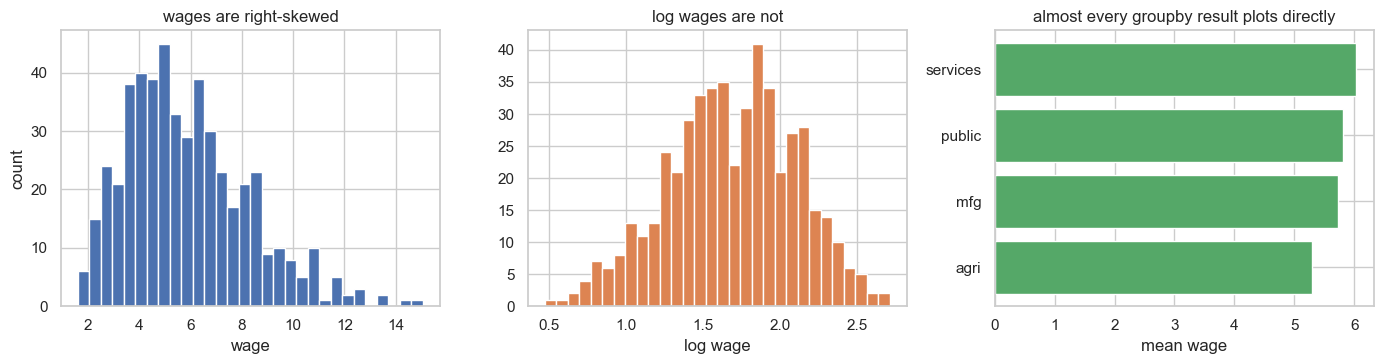

In [17]:
import seaborn as sns
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

axes[0].hist(panel["wage"], bins=30, edgecolor="white")
axes[0].set_xlabel("wage"); axes[0].set_ylabel("count")
axes[0].set_title("wages are right-skewed")

axes[1].hist(np.log(panel["wage"]), bins=30, edgecolor="white", color="C1")
axes[1].set_xlabel("log wage")
axes[1].set_title("log wages are not")

mean_by_sector = panel.groupby("sector")["wage"].mean().sort_values()
axes[2].barh(mean_by_sector.index, mean_by_sector.values, color="C2")
axes[2].set_xlabel("mean wage")
axes[2].set_title("almost every groupby result plots directly")

plt.tight_layout(); plt.show()

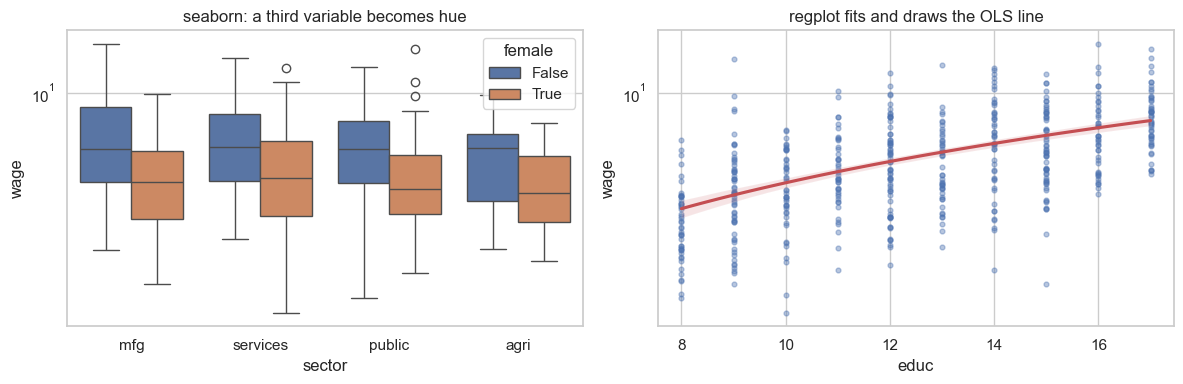

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=panel, x="sector", y="wage", hue="female", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("seaborn: a third variable becomes hue")

sns.regplot(data=panel, x="educ", y="wage", ax=axes[1],
            scatter_kws={"s": 12, "alpha": 0.4}, line_kws={"color": "C3"})
axes[1].set_yscale("log")
axes[1].set_title("regplot fits and draws the OLS line")

plt.tight_layout(); plt.show()

The log scale on both panels is not decoration. The data-generating process is multiplicative, the Mincer equation is linear in *log* wage, so a log axis is the one on which the model's structure is visible and the residual spread is roughly constant. Choosing the scale that matches the model is part of making a plot honest.

Two notes on style. **Colour carries information, but only if the palette suits the data type**: qualitative for categories, sequential for ordered scalars, diverging for signed quantities. And **one idea per chart**: a scatter with `hue` and `style` is fine; six variables on two axes is unreadable.

## 15. Worked example: building the matching matrix from marriage-census data

We can now close the loop that `fd02` opened.

`fd02` §12 built, by hand and with a dictionary, an index map from a pair $(x,y)$ to a position in a flat vector, and `fd08` §13 will assemble the constraint matrix of a transport problem out of Kronecker products, and `fd09` §6 will hand that matrix to `linprog` and read the multipliers as wages. Every one of those steps assumes a matrix $\mu_{xy}$ is already in hand. This section is where one comes from.

**This section produces one, from real data.** Choo and Siow (2006) study the US marriage market using census counts of marriages by the age of each spouse. The data are three plain text files: a $60\times60$ table of marriage counts for ages 16 to 75, and the numbers of available and single individuals of each age and sex.

In the notation of the series: $x$ indexes the husband's age, $y$ the wife's age, $\mu_{xy}$ is the mass of $(x,y)$ marriages, $n_x$ the mass of available men of age $x$, and $m_y$ of available women of age $y$.

In [19]:
from pathlib import Path

CHOO_SIOW_URL = ("https://raw.githubusercontent.com/math-econ-code/mec_optim_2021-01/"
                 "master/data_mec_optim/marriage-ChooSiow/")

def choo_siow_source():
    """Prefer a local copy of mec_datasets; fall back to the public repository."""
    here = Path.cwd()
    for parent in [here, *here.parents][:4]:
        candidate = parent / "mec_datasets" / "marriage-ChooSiow"
        if (candidate / "marr.txt").exists():
            return str(candidate) + "/", "local copy"
    return CHOO_SIOW_URL, "the math-econ-code repository"

source, where = choo_siow_source()
print(f"reading from {where}")

AGES = pd.Index(range(16, 76), name="x")
read = lambda name: pd.read_csv(source + name, sep="\t", header=None)

mu_x_y = read("marr.txt")
mu_x_y.index, mu_x_y.columns = AGES, AGES.rename("y")

avail = read("n_avail.txt")
singles = read("n_singles.txt")
n_x = pd.Series(avail[0].values, index=AGES, name="available_men")
m_y = pd.Series(avail[1].values, index=AGES.rename("y"), name="available_women")
single_men_x = pd.Series(singles[0].values, index=AGES, name="single_men")
single_women_y = pd.Series(singles[1].values, index=AGES.rename("y"), name="single_women")

print(f"\nmu_x_y is {mu_x_y.shape}: ages {AGES[0]} to {AGES[-1]}, both sexes")
print(f"total marriages   {mu_x_y.values.sum():>12,.0f}")
print(f"available men     {n_x.sum():>12,.0f}     single men   {single_men_x.sum():>12,.0f}")
print(f"available women   {m_y.sum():>12,.0f}     single women {single_women_y.sum():>12,.0f}")

reading from local copy

mu_x_y is (60, 60): ages 16 to 75, both sexes
total marriages      1,931,801
available men       10,446,141     single men      8,514,340
available women     12,973,301     single women   11,041,500


### The mass-balance identity

Before using these numbers we check them, and the check is the model's own accounting: **every available person is either married or single.** For each age $x$,

$$
\sum_y \mu_{xy} \;+\; \text{singles}_x \;=\; n_x, \tag{15.1}
$$

and symmetrically down the columns for women. This is exactly the constraint of the transport problem `fd09` §6 will solve, with an explicit outside option, so it is not merely a data-quality check but the feasibility condition of the matching model.

In [20]:
married_men_x = mu_x_y.sum(axis=1)               # sum over y: wives of every age
married_women_y = mu_x_y.sum(axis=0)             # sum over x

residual_men = (married_men_x + single_men_x - n_x).abs().max()
residual_women = (married_women_y + single_women_y - m_y).abs().max()

print(f"{'age x':>7}{'married men':>14}{'single men':>13}{'sum':>13}{'available':>13}")
print("-" * 60)
for x in (16, 25, 35, 50, 75):
    print(f"{x:>7}{married_men_x[x]:>14,.0f}{single_men_x[x]:>13,.0f}"
          f"{married_men_x[x] + single_men_x[x]:>13,.0f}{n_x[x]:>13,.0f}")
print("-" * 60)
print(f"max |sum_y mu_xy + singles_x - n_x| = {residual_men:.1f}")
print(f"max |sum_x mu_xy + singles_y - m_y| = {residual_women:.1f}")
assert residual_men == 0 and residual_women == 0
print("\ncheck passed: the identity holds EXACTLY, for every age and both sexes.")

  age x   married men   single men          sum    available
------------------------------------------------------------
     16        40,829    1,010,132    1,050,961    1,050,961
     25        67,045      152,228      219,273      219,273
     35        16,959       58,879       75,838       75,838
     50         8,649       74,657       83,306       83,306
     75         1,112       61,117       62,229       62,229
------------------------------------------------------------
max |sum_y mu_xy + singles_x - n_x| = 0.0
max |sum_x mu_xy + singles_y - m_y| = 0.0

check passed: the identity holds EXACTLY, for every age and both sexes.


Exactly zero, at every one of the 120 age–sex cells. That is a stronger statement than the tolerances used elsewhere in this series, and it is warranted here: these are *counts*, so the identity is an integer accounting statement, and any discrepancy at all would mean the three files disagree about who is in the sample.

### `stack` flattens row-major, and the `MultiIndex` is the index map

Now the connection this lecture has been building toward. `stack()` turns the $60\times60$ table into a long Series indexed by the *pair* $(x,y)$, and it does so in row-major order, $y$ varying fastest.

In [21]:
mu_xy = mu_x_y.stack(future_stack=True)          # long form: a MultiIndex Series
mu_xy.name = "marriages"

print(f"mu_x_y {mu_x_y.shape} -> mu_xy {mu_xy.shape}   ({60 * 60} pairs)")
print(f"index names {mu_xy.index.names}, first entries {list(mu_xy.index[:3])}\n")
print(mu_xy.head(4).to_string())

# 1. stack() flattens row-major -- fd08 section 13 gives this order a name
gap = np.abs(mu_xy.values - mu_x_y.values.reshape(-1)).max()
print(f"\nmax |stack() - reshape(-1)| = {gap:.1f}   (exact; tolerance 0)")
assert gap == 0

# 2. the MultiIndex position IS the fd02 index map, i * nby + j
nbx = nby = len(AGES)
idx_map = {(x, y): i * nby + j for i, x in enumerate(AGES) for j, y in enumerate(AGES)}
positions = [idx_map[key] for key in mu_xy.index]
assert positions == list(range(nbx * nby))
print(f"the MultiIndex enumerates pairs in exactly the fd02 order: {positions[:4]} ...")

# 3. unstack inverts stack
assert (mu_xy.unstack('y') == mu_x_y).all().all()
print("unstack('y') recovers the matrix exactly.")
print("\ncheck passed: the labelled long form and the bare flat vector are the")
print("same object, one carrying its index map and the other only positions.")

mu_x_y (60, 60) -> mu_xy (3600,)   (3600 pairs)
index names ['x', 'y'], first entries [(16, 16), (16, 17), (16, 18)]

x   y 
16  16    22704
    17    10954
    18     3932
    19     1550

max |stack() - reshape(-1)| = 0.0   (exact; tolerance 0)
the MultiIndex enumerates pairs in exactly the fd02 order: [0, 1, 2, 3] ...
unstack('y') recovers the matrix exactly.

check passed: the labelled long form and the bare flat vector are the
same object, one carrying its index map and the other only positions.


So the three representations of $\mu$ used across this series are one object seen three ways: a labelled table (`mu_x_y`), a labelled long Series whose index *is* the pair (`mu_xy`), and an unlabelled flat vector (`mu_x_y.values.reshape(-1)`) that a solver will accept. `stack` and `unstack` move between the first two; `.values` drops the labels to reach the third.

That is what pandas contributes to the workflow: it carries the index map as *data* rather than as a convention you must remember. `fd08` §12 will show the bug this prevents, pairing a Kronecker matrix built in one flattening convention with a vector flattened in the other, which raises nothing and returns wrong numbers, cannot happen while the labels are attached, because pandas aligns on them.

### Reading the data

With the object built and verified, a little economics.

distribution of (husband age - wife age):
  husband older        : 69.1%
  same age             : 14.2%
  wife older           : 16.7%
  mean gap             : +2.54 years
  modal gap            : +1 years


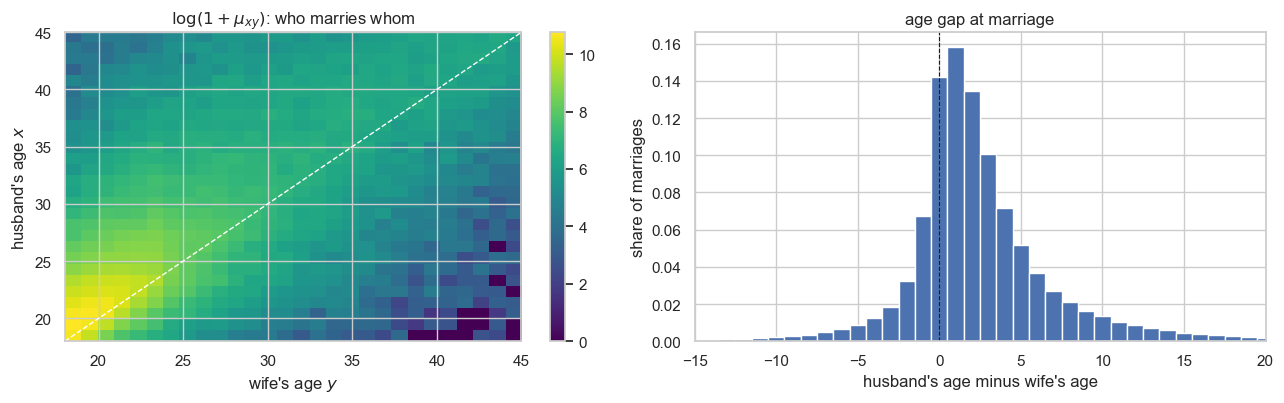

In [22]:
age_gap = (mu_xy.reset_index()
                .assign(gap=lambda d: d["x"] - d["y"])
                .groupby("gap")["marriages"].sum())
share = age_gap / age_gap.sum()

print("distribution of (husband age - wife age):")
print(f"  husband older        : {share[share.index > 0].sum():.1%}")
print(f"  same age             : {share[share.index == 0].sum():.1%}")
print(f"  wife older           : {share[share.index < 0].sum():.1%}")
print(f"  mean gap             : {(age_gap.index * share).sum():+.2f} years")
print(f"  modal gap            : {int(share.idxmax()):+d} years")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

sub = mu_x_y.loc[18:45, 18:45]
im = axes[0].imshow(np.log1p(sub.values), origin="lower", aspect="auto", cmap="viridis",
                    extent=[18, 45, 18, 45])
axes[0].plot([18, 45], [18, 45], "w--", lw=1)
axes[0].set_xlabel("wife's age $y$"); axes[0].set_ylabel("husband's age $x$")
axes[0].set_title(r"$\log(1+\mu_{xy})$: who marries whom")
fig.colorbar(im, ax=axes[0])

axes[1].bar(share.index, share.values, width=1.0)
axes[1].set_xlim(-15, 20); axes[1].axvline(0, color="k", lw=0.8, ls="--")
axes[1].set_xlabel("husband's age minus wife's age"); axes[1].set_ylabel("share of marriages")
axes[1].set_title("age gap at marriage")
plt.tight_layout(); plt.show()

The heat map is the empirical content of the matching model. Mass concentrates tightly along the diagonal, **positive assortative matching on age**, with a visible offset above it. The modal marriage has the husband just one year older, but the *mean* gap is $+2.5$ years and husbands are older in 69% of marriages against 17% where the wife is older. Mode and mean disagree because the distribution is sharply **right-skewed**: large positive gaps are far more common than large negative ones, and they drag the mean up without moving the peak. Quoting only one of the two summary numbers would misdescribe the market.

This is the object Becker's theory is about and the one `ot05` estimates a surplus function from. Choo and Siow's contribution was to show that under a separable surplus with logit heterogeneity, $\Phi_{xy}$ is *identified* from these counts alone, through

$$
\Phi_{xy} \;=\; 2\log\mu_{xy} - \log\mu_{x0} - \log\mu_{0y},
$$

where $\mu_{x0}$ and $\mu_{0y}$ are the singles we loaded. The surplus that `fd02` invented, and that `fd09` §6 will price, can on this data be *recovered*, and the whole computation begins with the `groupby` and `unstack` of this section.

One honest caveat about the picture, of the kind this series insists on: these are counts of marriages *formed*, not a random sample of couples, and the age composition of the available population is itself changing across the diagonal. The diagonal concentration therefore mixes preference for similar ages with the sheer availability of partners of each age, which is exactly why a model with the margins $n_x$ and $m_y$ in it, rather than a raw cross-tabulation, is needed to say anything about preferences. That model is `ot05`.

## 16. Summary

* pandas is NumPy with labels, and the labels do real work: **index alignment** makes arithmetic on two Series match by name rather than position, turning a class of silent misalignment bugs into visible `NaN`s.

* Choose an index deliberately and **verify that it identifies**: `verify_integrity=True` at creation, `validate=` on every merge. The default `how="inner"` drops unmatched rows without a word, which is the most common silent data-loss bug in applied work.

* Missingness is a dtype question. Under the legacy dtypes an integer column with one hole becomes `float64`; the nullable `Int64` keeps it integer by storing a mask. CSV preserves none of this and Parquet preserves all of it.

* **Split–apply–combine** covers most of what you do: aggregate to one row per group, transform to the same shape (the within transformation, whose group means are exactly zero: the defining property of the fixed-effects estimator), or filter whole groups.

* The economics is §15. From three text files of marriage counts we built $\mu_{xy}$, verified the mass-balance identity $\sum_y\mu_{xy} + \text{singles}_x = n_x$ **exactly** at all 120 age–sex cells, and produced the object the last four lectures of the series run on, with a `MultiIndex` that is `fd02`'s index map carrying names. The data show sharp positive assortative matching on age with a two-year male offset, and the model that separates preference from availability is `ot05`.

## 17. Exercises

Worked solutions are in §19.

**Exercise 1: A merge that loses data.** Add a row to `sector_info` for a sector `"finance"` that does not appear in `panel`, and *remove* the row for `"agri"`. Then merge with `panel` under all four `how` modes.

For each, report the number of rows, the number of `NaN`s introduced, and which sectors survive. Which mode silently loses observations, and which invents them? Then show how `validate="many_to_one"` and a `len` check before and after would have caught the problem, and state the rule you would adopt for every merge you ever write.

In [23]:
# your answer here


**Exercise 2: `.loc` against `.iloc`.** Using `panel`, and *without* converting to NumPy:

1. Select rows 10 through 15 inclusive with `.iloc`, then the same rows with `.loc`. Explain why the two calls need different arguments.
2. Select the `wage` and `educ` columns for all women in the manufacturing sector.
3. Set the `wage` of every row with `exper` missing to `NaN`, using the safe pattern of §9, and confirm no `SettingWithCopyWarning` is raised.
4. Explain, in one sentence, why `panel[panel["educ"] > 12]["wage"] = 0` is a bug even though it runs.

In [24]:
# your answer here


**Exercise 3: The gender pay gap, by sector.** A short tour of Part II on the wage panel.

Compute (i) the unconditional female/male mean-wage ratio; (ii) the same ratio by sector, using `groupby` and `unstack`; (iii) merge in `sector_info` and plot the sector-level ratio against `capital_intensity`, labelling each point.

Then the important part, which is not a computation. The data-generating process in §7 puts the *same* coefficient of $-0.20$ on `female` in every sector. So what is the across-sector variation in your estimated ratios, and how would you decide whether an apparent pattern in real data is anything more than what you are seeing here? Quantify it: give a standard error for each sector's ratio.

In [25]:
# your answer here


**Exercise 4: Missing-data hygiene.** Twelve rows of `panel` have `exper` missing.

Compare four treatments: drop the rows, fill with the column mean, fill with the *sector* mean (a `groupby().transform()`), and use a nullable `Int64` column: reporting for each the number of rows retained, the mean of `exper`, and the mean of `wage` among the affected rows.

Then reason about it: the holes were introduced *completely at random* by construction, so which treatments are unbiased here? Which would become biased if `exper` were instead missing more often for one sector, and why does mean-imputation understate the variance of `exper` in every case?

In [26]:
# your answer here


**Exercise 5: The marriage market in long form (proof, then computation).**

**(a) Prove** that `stack` and `unstack` are mutually inverse on a *complete* rectangular index: if $M$ is an $n_x\times n_y$ table with no missing entries, then `M.stack().unstack()` returns $M$, and the composition sends $M_{ij}$ to position $i\,n_y + j$ of the flat vector: the row-major flattening that `fd08` §12 names $\operatorname{vec}_C$. Say precisely where completeness is used, and what `unstack` produces when it fails.

**(b)** Verify it on `mu_x_y`, then delete a few entries and show what changes.

**(c)** Using the long form `mu_xy`, compute the mean wife's age for each husband's age, $\bar y(x) = \sum_y y\,\mu_{xy}/\sum_y\mu_{xy}$, and plot it against $x$ with the 45-degree line. Over which range is it close to linear, and what happens at the ends? Give one reason the relationship must flatten at the top of the age range that has nothing to do with preferences.

In [27]:
# your answer here


## 18. Further directions

`fd07` is about getting data in the first place: HTTP, JSON APIs, and HTML scraping, together with the question of how a result that depends on a live web request can be made reproducible at all: a problem this lecture's `generated/` folder only gestures at.

After that the scientific-computing block runs from `fd08` to `fd11`, NumPy, SciPy, differentiable programming, regularization, four lectures held together by a single idea about multipliers. `fd08` §13 is where §15 above gets its algebra: the `stack()` you performed on the marriage data turns out to have a name, $\operatorname{vec}_C$, and a Kronecker identity attached to it, and `fd09` §6 turns the resulting constraint matrix into wages.

Beyond the series, §15's $\mu_{xy}$ is where the masterclasses begin. `ot01` solves the assignment problem on it, `ot05` estimates the surplus $\Phi_{xy}$ from it by the Choo–Siow identification, and `dc01` supplies the logit heterogeneity that makes that identification work.

Save your work, restart the kernel, and run all cells top-to-bottom before you move on.

## 19. Solutions to the exercises

### Solution to Exercise 1: A merge that loses data

In [28]:
info_odd = (sector_info.query("sector != 'agri'")
            .pipe(lambda d: pd.concat([d, pd.DataFrame(
                {"sector": ["finance"], "capital_intensity": [0.55],
                 "union_rate": [0.05]})], ignore_index=True)))

print(f"panel has sectors      : {sorted(panel['sector'].unique())}")
print(f"info_odd has sectors   : {sorted(info_odd['sector'])}\n")
print(f"{'how':>8}{'rows':>8}{'NaNs':>8}   sectors in the result")
print("-" * 62)
for how in ("inner", "left", "right", "outer"):
    m = panel.merge(info_odd, on="sector", how=how)
    print(f"{how:>8}{len(m):>8}{int(m['capital_intensity'].isna().sum()):>8}   "
          f"{sorted(s for s in m['sector'].dropna().unique())}")
print("-" * 62)
print(f"panel had {len(panel)} rows")

panel has sectors      : ['agri', 'mfg', 'public', 'services']
info_odd has sectors   : ['finance', 'mfg', 'public', 'services']

     how    rows    NaNs   sectors in the result
--------------------------------------------------------------
   inner     479       0   ['mfg', 'public', 'services']
    left     500      21   ['agri', 'mfg', 'public', 'services']
   right     480       0   ['finance', 'mfg', 'public', 'services']
   outer     501      21   ['agri', 'finance', 'mfg', 'public', 'services']
--------------------------------------------------------------
panel had 500 rows


**Which mode loses, and which invents.** `inner` silently *drops* the 26 agricultural workers, because `"agri"` is absent from the right table: the result simply has fewer rows and nothing says so. `right` and `outer` *invent* a row: `"finance"` has no workers in `panel`, so the merge emits a row whose entire left-hand side is `NaN`, a phantom observation of a sector nobody works in. `left` is the only mode that preserves the left frame exactly, marking unmatched rows with `NaN`.

Note that `inner` is the **default**. A merge written without thinking about `how` is a merge that may quietly discard part of the sample.

In [29]:
# how the problem would have been caught
before = len(panel)
after = len(panel.merge(info_odd, on="sector", how="inner"))
print(f"row count before {before}, after {after}: {before - after} rows lost")
assert before != after                                   # the check that should fire

# validate= catches the OTHER failure: an unexpected duplicate on the right
dup_info = pd.concat([sector_info, sector_info.head(1)], ignore_index=True)
try:
    panel.merge(dup_info, on="sector", how="left", validate="many_to_one")
except pd.errors.MergeError as err:
    print(f"validate='many_to_one' -> MergeError: {err}")

n_dup = len(panel.merge(dup_info, on="sector", how="left"))
print(f"without validate=, the same merge returns {n_dup} rows from {len(panel)} "
      f"-- {n_dup - len(panel)} duplicated")

row count before 500, after 479: 21 rows lost
validate='many_to_one' -> MergeError: Merge keys are not unique in right dataset; not a many-to-one merge
without validate=, the same merge returns 604 rows from 500 -- 104 duplicated


**The rule worth adopting.** Every merge gets three things: an explicit `how=`, a `validate=` naming the relationship you believe holds, and an assertion on the row count. That is three lines for an operation that is otherwise the single most common source of silent data corruption in empirical work: a merge that drops a tenth of the sample, or duplicates it, produces results that are perfectly reproducible and simply wrong. It is the same argument `fd03` made for checking a solver's convergence flag: the failure is silent unless you make it loud.

### Solution to Exercise 2: `.loc` against `.iloc`

In [30]:
work = panel.copy()

# 1. the same rows, two ways
by_position = work.iloc[10:16]                    # END-EXCLUSIVE: 10..15
by_label = work.loc[10:15]                        # END-INCLUSIVE: 10..15
print(f"iloc[10:16] -> {len(by_position)} rows; loc[10:15] -> {len(by_label)} rows; "
      f"identical: {by_position.equals(by_label)}")

# 2. two conditions and two columns
women_mfg = work.loc[(work["female"]) & (work["sector"] == "mfg"), ["wage", "educ"]]
print(f"\nwomen in manufacturing: {len(women_mfg)} rows")
print(women_mfg.head(3))

# 3. the safe assignment pattern
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("error")                # any warning becomes an exception
    work.loc[work["exper"].isna(), "wage"] = np.nan
print(f"\nrows with wage now missing: {int(work['wage'].isna().sum())}  (no warning raised)")

iloc[10:16] -> 6 rows; loc[10:15] -> 6 rows; identical: True

women in manufacturing: 55 rows
   wage  educ
0  4.22     8
2  4.48    14
3  5.82    12

rows with wage now missing: 12  (no warning raised)


**Why the two calls need different arguments.** `panel`'s index happens to be the default `RangeIndex`, so labels and positions coincide *numerically*, but they remain different things, and pandas slices them by different rules. `.iloc[10:16]` is a positional slice and follows Python's end-exclusive convention; `.loc[10:15]` is a label slice and is end-inclusive, for the reason given in §5: labels have no successor. Had the index been country names or dates, `.iloc[10:16]` would still work and `.loc[10:15]` would raise.

**Why `panel[panel["educ"] > 12]["wage"] = 0` is a bug.** The first bracket returns a *new object*, pandas may give a copy, so the assignment writes into that temporary and the original `panel` may be untouched. The statement runs, no error appears, and the data are silently unmodified (or modified, depending on internals). It is the chained-indexing trap of §9; `panel.loc[panel["educ"] > 12, "wage"] = 0` addresses one object once and always works.

### Solution to Exercise 3: The gender pay gap, by sector

In [31]:
gap_total = panel.groupby("female")["wage"].mean()
ratio_total = gap_total[True] / gap_total[False]
print(f"mean wage male {gap_total[False]:.2f}, female {gap_total[True]:.2f}, "
      f"ratio {ratio_total:.3f}")

by_sector = (panel.groupby(["sector", "female"])["wage"].mean()
                  .unstack("female").rename(columns={False: "male", True: "female"}))
by_sector["ratio"] = by_sector["female"] / by_sector["male"]

# a standard error for each ratio, by the delta method on log means
stats = panel.groupby(["sector", "female"])["wage"].agg(["mean", "std", "size"])
se_ratio = {}
for sector in by_sector.index:
    m, f = stats.loc[(sector, False)], stats.loc[(sector, True)]
    rel_var = (m["std"] ** 2 / m["size"]) / m["mean"] ** 2 + (f["std"] ** 2 / f["size"]) / f["mean"] ** 2
    se_ratio[sector] = by_sector.loc[sector, "ratio"] * np.sqrt(rel_var)
by_sector["se"] = pd.Series(se_ratio)

with_cov = by_sector.merge(sector_info.set_index("sector"), left_index=True, right_index=True)
print(f"\n{with_cov[['male', 'female', 'ratio', 'se', 'capital_intensity']].round(3)}")

mean wage male 6.63, female 5.16, ratio 0.778

           male  female  ratio     se  capital_intensity
sector                                                  
agri      5.920   4.717  0.797  0.126               0.48
mfg       6.733   4.835  0.718  0.055               0.62
public    6.428   5.111  0.795  0.063               0.25
services  6.737   5.339  0.793  0.037               0.31


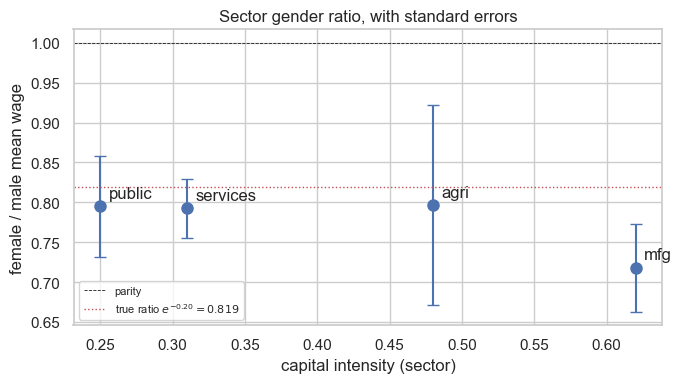

spread of ratios across sectors : 0.079
typical standard error          : 0.070
spread / typical SE             : 1.1


In [32]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(with_cov["capital_intensity"], with_cov["ratio"], yerr=with_cov["se"],
            fmt="o", ms=8, capsize=4)
for sector, row in with_cov.iterrows():
    ax.annotate(sector, (row["capital_intensity"], row["ratio"]),
                xytext=(6, 6), textcoords="offset points")
ax.axhline(1.0, color="k", lw=0.6, ls="--", label="parity")
ax.axhline(np.exp(-0.20), color="C3", lw=1, ls=":", label=r"true ratio $e^{-0.20}=0.819$")
ax.set_xlabel("capital intensity (sector)"); ax.set_ylabel("female / male mean wage")
ax.set_title("Sector gender ratio, with standard errors")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

spread = with_cov["ratio"].max() - with_cov["ratio"].min()
typical_se = with_cov["se"].mean()
print(f"spread of ratios across sectors : {spread:.3f}")
print(f"typical standard error          : {typical_se:.3f}")
print(f"spread / typical SE             : {spread / typical_se:.1f}")

**What the across-sector variation is.** Noise. The data-generating process of §7 applies the same $-0.20$ coefficient in every sector, so the *true* ratio is $e^{-0.20} = 0.819$ everywhere and every deviation from it is sampling error. The spread across sectors is almost exactly one typical standard error, which is what that diagnosis predicts.

Look closely at manufacturing, though. Its estimated ratio of $0.718$ sits about **1.8 standard errors below** the truth, and its one-standard-error bar does not reach the true line: the only sector of which that is true. In real data this is the sector you would be tempted to write a paragraph about. It is also exactly what one expects to see somewhere among four independent estimates: the probability that at least one of four lands beyond $1.8$ standard errors is around a quarter. Selecting the extreme cell is the source of the bias, and `fd11` §9 will give it a name: it is post-selection inference, and there it costs a nominal 95% confidence interval two thirds of its coverage.

**How you would decide in real data.** Precisely as here: put a standard error on each group estimate before interpreting differences between them. A pattern is worth a sentence only if it is large relative to the uncertainty in the individual estimates, and with four sectors and a few dozen observations in the smallest, it will rarely be. The strong temptation, when a table of four numbers is not identical, is to narrate the ordering; the discipline is to notice that `agri` has 26 observations and therefore an enormous standard error.

Two further cautions. The unconditional ratio is not a causal estimate of anything: it confounds whatever else differs by sex, which is nothing here by construction and a great deal in real data. And note the direction of the bias if you *selected* the sector with the largest gap to report: that is the post-selection problem again, which `fd11` §9 measures.

### Solution to Exercise 4: Missing-data hygiene

In [33]:
affected = panel["exper"].isna()
print(f"{int(affected.sum())} rows have exper missing\n")

treatments = {
    "drop rows": panel.dropna(subset=["exper"]),
    "fill column mean": panel.assign(exper=panel["exper"].fillna(panel["exper"].mean())),
    "fill sector mean": panel.assign(
        exper=panel["exper"].fillna(panel.groupby("sector")["exper"].transform("mean"))),
    "nullable Int64": panel.assign(exper=panel["exper"].astype("Int64")),
}

print(f"{'treatment':<20}{'rows':>7}{'mean exper':>13}{'sd exper':>11}{'mean wage':>12}")
print("-" * 63)
for name, frame in treatments.items():
    e = frame["exper"].astype("float")
    print(f"{name:<20}{len(frame):>7}{e.mean():>13.3f}{e.std():>11.3f}"
          f"{frame['wage'].mean():>12.2f}")
print("-" * 63)
print(f"{'(complete cases)':<20}{int((~affected).sum()):>7}"
      f"{panel.loc[~affected, 'exper'].mean():>13.3f}"
      f"{panel.loc[~affected, 'exper'].std():>11.3f}"
      f"{panel.loc[~affected, 'wage'].mean():>12.2f}")

# the deflation of the sd under mean imputation is predictable, so check it
n_total, n_miss = len(panel), int(affected.sum())
sd_complete = panel.loc[~affected, "exper"].std()
sd_imputed = treatments["fill column mean"]["exper"].std()
predicted = np.sqrt((n_total - n_miss - 1) / (n_total - 1))
print(f"\nsd after mean-imputation / sd of complete cases = {sd_imputed / sd_complete:.5f}")
print(f"predicted sqrt((n - n_miss - 1)/(n - 1))        = {predicted:.5f}")
assert abs(sd_imputed / sd_complete - predicted) < 5e-3
print("check passed: mean imputation deflates the sd by exactly the predicted factor.")

12 rows have exper missing

treatment              rows   mean exper   sd exper   mean wage
---------------------------------------------------------------
drop rows               488       14.697      8.731        5.89
fill column mean        500       14.697      8.626        5.88
fill sector mean        500       14.695      8.626        5.88
nullable Int64          500       14.697      8.731        5.88
---------------------------------------------------------------
(complete cases)        488       14.697      8.731        5.89

sd after mean-imputation / sd of complete cases = 0.98790
predicted sqrt((n - n_miss - 1)/(n - 1))        = 0.98790
check passed: mean imputation deflates the sd by exactly the predicted factor.


**Which treatments are unbiased here.** All of them, for the *mean*, because §7 knocked out the twelve values with `rng.choice`, independently of everything else, so the data are **missing completely at random** (MCAR). Under MCAR the complete cases are a random subsample, so dropping rows is unbiased; and filling with the mean preserves the mean by construction.

**What would break it.** If `exper` went missing more often in one sector, say because that sector's survey form was different, the data would be *missing at random* conditional on sector but not MCAR unconditionally. Dropping rows would then over-weight the sectors with better response, biasing any statistic that differs across sectors, and filling with the *column* mean would import the pooled mean into a sector whose true mean differs. Filling with the *sector* mean survives this case, which is why the `groupby().transform()` version is the better default. If missingness depended on the unobserved value itself, high-experience workers declining to answer, no imputation scheme based on observables recovers the truth, and the problem becomes one of selection rather than of data cleaning.

**Why mean imputation always understates the variance.** Every imputed value is placed exactly at the mean, so the filled observations contribute zero to the sum of squared deviations. With $n_{\text{miss}}$ of $n$ values replaced by the mean, the sum of squared deviations is unchanged while the divisor grows, so the standard deviation is deflated by a factor $\sqrt{(n-n_{\text{miss}}-1)/(n-1)}$: the check above confirms it to five decimals. Here that is only a 1% effect because twelve of five hundred values are missing; with 20% missing it would be a 10% understatement of the standard deviation, and of every standard error computed from it. Any standard error computed from the imputed column is therefore too small, which is the reason multiple imputation exists: it restores the variability by drawing the fills from a distribution rather than pinning them to a point.

### Solution to Exercise 5: The marriage market in long form

**(a) Proof.** Let $M$ be a table with row index $\{x_0,\dots,x_{n_x-1}\}$ and column index $\{y_0,\dots,y_{n_y-1}\}$, complete in the sense that $M_{ij}$ is present for every pair.

`M.stack()` produces a Series whose index is the set of pairs $(x_i,y_j)$, enumerated with the row index outer and the column index inner, that is, in the order $(x_0,y_0), (x_0,y_1),\dots,(x_0,y_{n_y-1}),(x_1,y_0),\dots$, so the entry $M_{ij}$ lands at position $i\,n_y + j$. That is precisely the row-major map $\operatorname{idx}(i,j) = i\,n_y+j$ of `fd02` §12, hence $\operatorname{vec}_C$.

`unstack()` inverts this by reading the last index level back out into columns: the entry with key $(x_i,y_j)$ is placed at row $x_i$, column $y_j$. Since every pair occurs exactly once, the map pairs $\to$ cells is a bijection, and the composition is the identity. $\blacksquare$

**Where completeness is used.** Only in the last step. (The cell below raises a `FutureWarning` from `stack(dropna=True)`: pandas is in the middle of replacing this method's implementation, and `future_stack=True` opts into the new one. That is left visible on purpose: an API that changes under you between minor versions is exactly the reproducibility hazard `fd07` addresses, and pinning `pandas` in an environment file is the answer.)

`stack` is well defined for any table, but it *omits missing entries* by default, so if $M$ has holes the resulting index is a strict subset of the product and `unstack` must invent something for the absent cells: it fills them with `NaN`. The round trip then returns a table equal to $M$ wherever $M$ was present and `NaN` elsewhere, which is $M$ again only if $M$ had no holes to begin with. Passing `dropna=False` (or, in current pandas, `future_stack=True`, which keeps missing entries) makes the round trip exact regardless.

In [34]:
import warnings

# (b) verify, then break it
round_trip = mu_x_y.stack(future_stack=True).unstack("y")
print(f"complete table: round trip exact -> {bool((round_trip == mu_x_y).all().all())}")

holed = mu_x_y.copy().astype(float)
holed.iloc[0, 0] = np.nan
holed.iloc[5, 7] = np.nan

with warnings.catch_warnings(record=True) as caught:   # deliberate, see the note above
    warnings.simplefilter("always")
    dropped = holed.stack(dropna=True)
for w in caught:
    print(f"{w.category.__name__}: {str(w.message).splitlines()[0][:86]}")
kept = holed.stack(future_stack=True)
print(f"\nwith 2 holes: stack(dropna=True) has {len(dropped)} entries, "
      f"stack(future_stack=True) has {len(kept)} (of {60 * 60})")
print(f"round trip via dropna=True recovers the shape: "
      f"{dropped.unstack('y').shape == mu_x_y.shape}")
print(f"...but the two holes come back as NaN: "
      f"{int(dropped.unstack('y').isna().sum().sum())} missing cells")

complete table: round trip exact -> True

with 2 holes: stack(dropna=True) has 3598 entries, stack(future_stack=True) has 3600 (of 3600)
round trip via dropna=True recovers the shape: True
...but the two holes come back as NaN: 2 missing cells


wide and long agree: max gap 0.00e+00   (tolerance 1e-9)


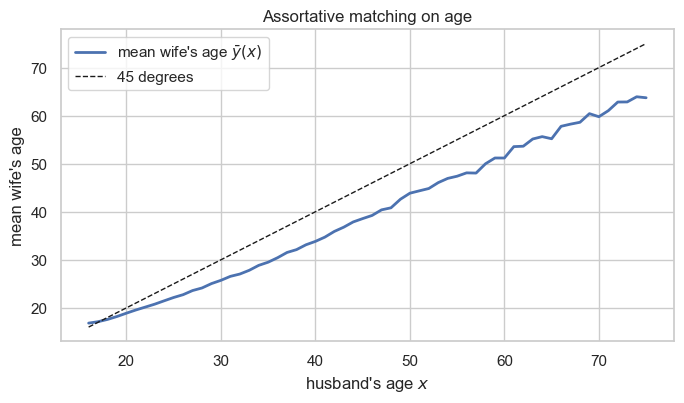

slope over ages 22-50 : 0.834
mean offset there     : +5.05 years
at age 70, mean wife's age is 59.8 -- an offset of +10.2 years


In [35]:
# (c) mean wife's age for each husband's age
totals_x = mu_x_y.sum(axis=1)
mean_wife_x = (mu_x_y * mu_x_y.columns.values).sum(axis=1) / totals_x

# the same thing from the long form, to check
from_long = (mu_xy.reset_index()
                  .assign(prod=lambda d: d["y"] * d["marriages"])
                  .groupby("x")
                  .apply(lambda d: d["prod"].sum() / d["marriages"].sum(),
                         include_groups=False))
gap = (mean_wife_x - from_long).abs().max()
print(f"wide and long agree: max gap {gap:.2e}   (tolerance 1e-9)")
assert gap < 1e-9

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(mean_wife_x.index, mean_wife_x.values, lw=2, label=r"mean wife's age $\bar y(x)$")
ax.plot([16, 75], [16, 75], "k--", lw=1, label="45 degrees")
ax.set_xlabel("husband's age $x$"); ax.set_ylabel("mean wife's age")
ax.set_title("Assortative matching on age")
ax.legend(); plt.tight_layout(); plt.show()

lin = mean_wife_x.loc[22:50]
slope = np.polyfit(lin.index, lin.values, 1)[0]
print(f"slope over ages 22-50 : {slope:.3f}")
print(f"mean offset there     : {(lin.index.to_numpy() - lin.values).mean():+.2f} years")
print(f"at age 70, mean wife's age is {mean_wife_x[70]:.1f} -- an offset of "
      f"{70 - mean_wife_x[70]:+.1f} years")

Between roughly 22 and 50 the relationship is close to linear, but its slope is $0.83$ rather than $1$. That matters: a slope below one means the age gap **widens** with the husband's age rather than staying constant. Each extra year of a husband's age is associated with only about ten months of his wife's, so the mean offset over this range is about five years and grows steadily across it.

Note also that this five-year figure is *not* the $+2.5$ years computed in §15, and the difference is a weighting one rather than a contradiction. §15 averaged over marriages, which are concentrated at young ages where the gap is small; here we average the per-age offsets without weighting, so the sparsely populated older ages, where the gap is large, count as much as the crowded young ones. Both numbers are correct answers to different questions, and the discipline is to say which one you are quoting.

**At the ends it flattens, and for a reason with nothing to do with preferences.** The age range is *truncated at 16 and 75*. A 70-year-old man cannot marry a woman of 68 more often than the data permit, because the pool thins rapidly, but he faces no corresponding restriction below, so the mean of his wives' ages is dragged downward by the availability of younger women and cannot be dragged upward by anyone beyond 75. The same mechanism operates in reverse at the bottom of the range. The apparent "preference" for a larger age gap at older ages is therefore partly a boundary artefact of the sample's age window.

This is exactly why a raw cross-tabulation cannot be read as a statement about preferences, and why the model of `ot05` carries the margins $n_x$ and $m_y$ explicitly: dividing through by availability is what separates *who is preferred* from *who is around*. The lecture's last verification, that $\sum_y\mu_{xy} + \text{singles}_x = n_x$ holds exactly, is what makes that division legitimate.